# Predictive Analytics: Synthetic Data, Stock LSTM, Sales Forecast, Tips Regression
### United International University, Real-Life Project

One notebook, run top to bottom:
1. **Part 0**: generate the synthetic dataset (writes `predictive_analytics_dataset_synthetic.xlsx`)
2. **Part 1**: stock price LSTM
3. **Part 2**: sales forecasting
4. **Part 3**: waiter tips regression
5. **Part 4**: save and reload the tips pipeline

Requires: `numpy pandas matplotlib scikit-learn statsmodels tensorflow openpyxl joblib`.

The data is **synthetic** (different generator, tickers, stores, dates and seed from the class demo), so scores describe how methods fit the generator, not real markets.

## Part 0: Generate the synthetic dataset
Stocks are random walks with volatility clustering (no built-in predictable pattern). Sales have trend, weekly and annual seasonality, promotions and noise. Tips are mostly proportional to the bill with small day/time/size effects.

In [1]:
import numpy as np
import pandas as pd

SEED = 2026
rng = np.random.default_rng(SEED)

In [2]:
# ---------------------------------------------------------------- stocks ----
def make_stock(ticker, start_price, mu_annual, base_vol, n=750, start="2022-06-01"):
    """Geometric random walk with volatility clustering (GARCH(1,1)-style).
    No hand-built predictable pattern: next-day returns are (nearly) unpredictable,
    which is the realistic situation a model has to cope with."""
    dates = pd.bdate_range(start, periods=n)
    omega, alpha, beta = 0.05 * base_vol**2, 0.08, 0.90
    var = base_vol**2
    closes, rets = [], []
    price = start_price
    for _ in range(n):
        eps = rng.standard_normal()
        r = mu_annual / 252 + np.sqrt(var) * eps
        price *= np.exp(r)
        closes.append(price)
        rets.append(r)
        var = omega + alpha * (np.sqrt(var) * eps) ** 2 + beta * var
    close = np.array(closes)
    prev_close = np.concatenate([[start_price], close[:-1]])
    open_ = prev_close * (1 + rng.normal(0, base_vol * 0.25, n))
    intraday = np.abs(rng.normal(0, base_vol * 0.6, n))
    high = np.maximum(open_, close) * (1 + intraday)
    low = np.minimum(open_, close) * (1 - intraday)
    vol = rng.lognormal(mean=13.6, sigma=0.25, size=n) * (1 + 18 * np.abs(rets))
    return pd.DataFrame({
        "date": dates.strftime("%Y-%m-%d"), "ticker": ticker,
        "open": open_.round(2), "high": high.round(2), "low": low.round(2),
        "close": close.round(2), "volume": vol.astype(int),
    })


stocks = pd.concat([
    make_stock("BANKNOVA", 85.0, 0.10, 0.011),
    make_stock("SOLARIS", 40.0, 0.28, 0.022),
    make_stock("RETAILHUB", 120.0, 0.04, 0.014),
], ignore_index=True)

In [3]:
# ----------------------------------------------------------------- sales ----
def make_sales(store, base, trend_per_day, weekly, annual_amp, noise_sd, n=730, start="2023-07-01"):
    """Level + linear trend, weekly pattern, annual seasonality, a few
    promotion spikes, and multiplicative noise."""
    dates = pd.date_range(start, periods=n, freq="D")
    t = np.arange(n)
    dow = dates.dayofweek.values                      # Mon=0 ... Sun=6
    week_effect = np.array(weekly)[dow]
    annual = annual_amp * np.sin(2 * np.pi * (t - 60) / 365.25)
    level = base + trend_per_day * t
    promo = np.zeros(n)
    for d in rng.choice(np.arange(20, n - 5), size=8, replace=False):
        promo[d:d + 3] += rng.uniform(0.15, 0.30) * base     # 3-day promotion bump
    mult = rng.normal(1.0, noise_sd, n)
    sales = (level * (1 + week_effect) + annual + promo) * mult
    return pd.DataFrame({"date": dates.strftime("%Y-%m-%d"), "store": store, "sales": sales.round(1)})


#                       Mon    Tue    Wed    Thu    Fri    Sat   Sun
W = [-0.10, -0.12, -0.08, -0.02, 0.18, 0.22, 0.06]
sales = pd.concat([
    make_sales("Gulshan", 900, 0.45, W, 70, 0.045),
    make_sales("Dhanmondi", 700, 0.30, [x * 0.8 for x in W], 55, 0.050),
    make_sales("Uttara", 520, 0.55, [x * 1.1 for x in W], 40, 0.060),
    make_sales("Motijheel", 640, 0.10, [-0.05, -0.04, -0.02, 0.0, 0.10, 0.14, 0.02], 60, 0.055),
], ignore_index=True)

In [4]:
# ------------------------------------------------------------------ tips ----
def make_tips(n=300):
    day = rng.choice(["Thur", "Fri", "Sat", "Sun"], n, p=[0.22, 0.14, 0.36, 0.28])
    time = np.where(np.isin(day, ["Sat", "Sun"]), rng.choice(["Dinner", "Lunch"], n, p=[0.8, 0.2]),
                    rng.choice(["Dinner", "Lunch"], n, p=[0.35, 0.65]))
    size = rng.choice([1, 2, 3, 4, 5, 6], n, p=[0.06, 0.45, 0.17, 0.20, 0.08, 0.04])
    sex = rng.choice(["Male", "Female"], n, p=[0.55, 0.45])
    smoker = rng.choice(["No", "Yes"], n, p=[0.65, 0.35])
    # bill grows with party size and is higher at dinner
    bill = rng.gamma(shape=6.0, scale=1.0, size=n) * (3.2 + 1.4 * size) * np.where(time == "Dinner", 1.15, 1.0) / 2.2
    bill = np.clip(bill, 6, 70)
    # tip: mostly proportional to the bill; small size/dinner/weekend effects; heavy-ish noise
    tip = (0.35 + 0.115 * bill + 0.10 * (size - 2) + 0.30 * (time == "Dinner")
           + 0.20 * (day == "Sat") + rng.normal(0, 0.55 + 0.012 * bill, n))
    tip = np.clip(tip, 0.5, None)
    return pd.DataFrame({"total_bill": bill.round(2), "tip": tip.round(2), "sex": sex,
                         "smoker": smoker, "day": day, "time": time, "size": size})


tips = make_tips()

out = "predictive_analytics_dataset_synthetic.xlsx"
with pd.ExcelWriter(out) as xw:
    stocks.to_excel(xw, sheet_name="Stock_Prices", index=False)
    sales.to_excel(xw, sheet_name="Sales_Data", index=False)
    tips.to_excel(xw, sheet_name="Waiter_Tips", index=False)
print(f"Wrote {out}: stocks {stocks.shape}, sales {sales.shape}, tips {tips.shape}")

Wrote predictive_analytics_dataset_synthetic.xlsx: stocks (2250, 7), sales (2920, 3), tips (300, 7)


In [5]:
print(stocks.groupby('ticker').close.agg(['first','last','min','max']))
print(sales.groupby('store').sales.describe()[['mean','min','max']])
tips.head()

            first    last    min     max
ticker                                  
BANKNOVA    84.30  229.97  82.88  237.73
RETAILHUB  120.63  175.38  95.21  243.07
SOLARIS     39.65  129.00  30.04  167.99
                  mean    min     max
store                                
Dhanmondi   829.631918  548.8  1320.7
Gulshan    1091.392740  678.0  1597.3
Motijheel   696.820959  516.4  1017.7
Uttara      737.556301  391.8  1335.8


,total_bill,tip,sex,smoker,day,time,size
0,25.01,5.46,Female,No,Fri,Dinner,2
1,20.04,1.87,Male,No,Thur,Dinner,4
2,10.98,0.93,Male,Yes,Thur,Lunch,2
3,30.95,4.79,Male,No,Sat,Dinner,5
4,12.62,2.15,Male,Yes,Thur,Lunch,2


## Setup for the analysis

In [6]:
import json, os, warnings
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib

DATA = "predictive_analytics_dataset_synthetic.xlsx"
R = {}
rmse = lambda a, b: float(np.sqrt(mean_squared_error(a, b)))
C = dict(teal="#0E7C86", amber="#F2A03D", navy="#0F2C3D", sage="#8FBF9F")
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

I0000 00:00:1791007385.761849    2011 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791007387.057192    2011 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Part 1: Stock price prediction (LSTM)
20-day sliding windows over BANKNOVA closing prices, time-based 80/20 split, scaler fitted on train only, early stopping on a validation slice of the *training* data. The same model is also run on the other two tickers and 3 seeds each, and compared with a naive 'yesterday's close' baseline.

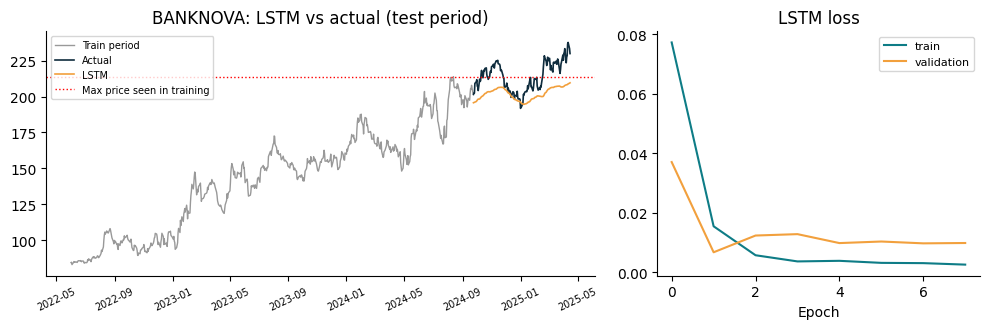

In [7]:
stock = pd.read_excel(DATA, sheet_name="Stock_Prices", parse_dates=["date"])
WINDOW, EPOCHS = 20, 40

def run_lstm(close, seed):
    """Sliding windows over closing price; TIME-BASED split; scaler fitted on TRAIN only
    (fitting it on all data would leak test-period price range into training)."""
    n_win = len(close) - WINDOW
    split = int(n_win * 0.8)                       # first 80% of windows = train
    train_end = split + WINDOW                     # last train price index (exclusive)
    scaler = MinMaxScaler().fit(close[:train_end].reshape(-1, 1))
    s = scaler.transform(close.reshape(-1, 1)).ravel()
    X = np.array([s[i - WINDOW:i] for i in range(WINDOW, len(s))])[..., None]
    y = np.array([s[i] for i in range(WINDOW, len(s))])
    Xtr, Xte, ytr, yte = X[:split], X[split:], y[:split], y[split:]
    tf.keras.utils.set_random_seed(seed)
    m = keras.Sequential([keras.layers.Input((WINDOW, 1)), keras.layers.LSTM(32),
                          keras.layers.Dense(16, activation="relu"), keras.layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse")
    # validation = last 15% of TRAIN (not the test set) for early stopping
    h = m.fit(Xtr, ytr, epochs=EPOCHS, batch_size=16, validation_split=0.15, shuffle=False, verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
    pred = scaler.inverse_transform(m.predict(Xte, verbose=0)).ravel()
    actual = close[WINDOW + split:]
    naive = close[WINDOW + split - 1:-1]           # yesterday's close
    return dict(pred=pred, actual=actual, naive=naive, hist=h.history, split=split,
                train_max=float(close[:train_end].max()), test_max=float(actual.max()),
                frac_above=float((actual > close[:train_end].max()).mean()))

stock_res = {}
for tk in ["BANKNOVA", "SOLARIS", "RETAILHUB"]:
    d = stock[stock.ticker == tk].sort_values("date").reset_index(drop=True)
    close = d.close.values
    runs = [run_lstm(close, s) for s in (42, 43, 44)]
    r0 = runs[0]
    stock_res[tk] = dict(
        lstm_rmse_seeds=[rmse(r["actual"], r["pred"]) for r in runs],
        naive_rmse=rmse(r0["actual"], r0["naive"]),
        train_max=r0["train_max"], test_max=r0["test_max"], frac_test_above_train_max=r0["frac_above"],
        n_train_windows=r0["split"], n_test=len(r0["actual"]),
        test_start=str(d.date.values[WINDOW + r0["split"]])[:10], test_end=str(d.date.values[-1])[:10],
        mean_test_price=float(r0["actual"].mean()),
        bias_seed0=float(np.mean(r0["pred"] - r0["actual"])))
    if tk == "BANKNOVA":
        dates = d.date.values[WINDOW + r0["split"]:]
        fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [1.7, 1]})
        ax[0].plot(d.date.values[:WINDOW + r0["split"]], close[:WINDOW + r0["split"]], color="#999", lw=1, label="Train period")
        ax[0].plot(dates, r0["actual"], color=C["navy"], lw=1.2, label="Actual")
        ax[0].plot(dates, r0["pred"], color=C["amber"], lw=1.2, label="LSTM")
        ax[0].axhline(r0["train_max"], color="red", ls=":", lw=1, label="Max price seen in training")
        ax[0].tick_params(axis="x", labelsize=7, rotation=25); ax[0].set_title("BANKNOVA: LSTM vs actual (test period)"); ax[0].legend(fontsize=7, loc="upper left")
        ax[1].plot(r0["hist"]["loss"], color=C["teal"], label="train"); ax[1].plot(r0["hist"]["val_loss"], color=C["amber"], label="validation")
        ax[1].set_title("LSTM loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(fontsize=8)
        plt.tight_layout(); plt.show()
R["stock"] = stock_res

**Read this honestly:** if the LSTM RMSE is above the naive RMSE, the model has learned nothing useful beyond persistence. Note also `frac_test_above_train_max`: a price-level LSTM cannot predict above prices it has seen.

In [8]:
pd.DataFrame({tk: {'LSTM RMSE seed 42': v['lstm_rmse_seeds'][0], 'LSTM RMSE seed 43': v['lstm_rmse_seeds'][1], 'LSTM RMSE seed 44': v['lstm_rmse_seeds'][2], 'Naive RMSE': v['naive_rmse'], 'Test days above train max': v['frac_test_above_train_max']} for tk, v in stock_res.items()}).round(2).T

,LSTM RMSE seed 42,LSTM RMSE seed 43,LSTM RMSE seed 44,Naive RMSE,Test days above train max
BANKNOVA,13.82,15.37,8.44,3.06,0.48
SOLARIS,8.26,7.91,5.54,3.48,0.00
RETAILHUB,9.76,23.04,8.97,7.03,0.17


**Why the split must be by time:** a random split would place days from the middle of the series in training, so the model predicts days whose neighbours it has already seen (interpolation, not forecasting). Overlapping 20-day windows would also leak almost identical examples across train and test, giving an unrealistically low error.

## Part 2: Sales forecasting (Gulshan store)
Decomposition (period 7), then Holt-Winters variants, SARIMA and two baselines on the last 60 days (time-based split).

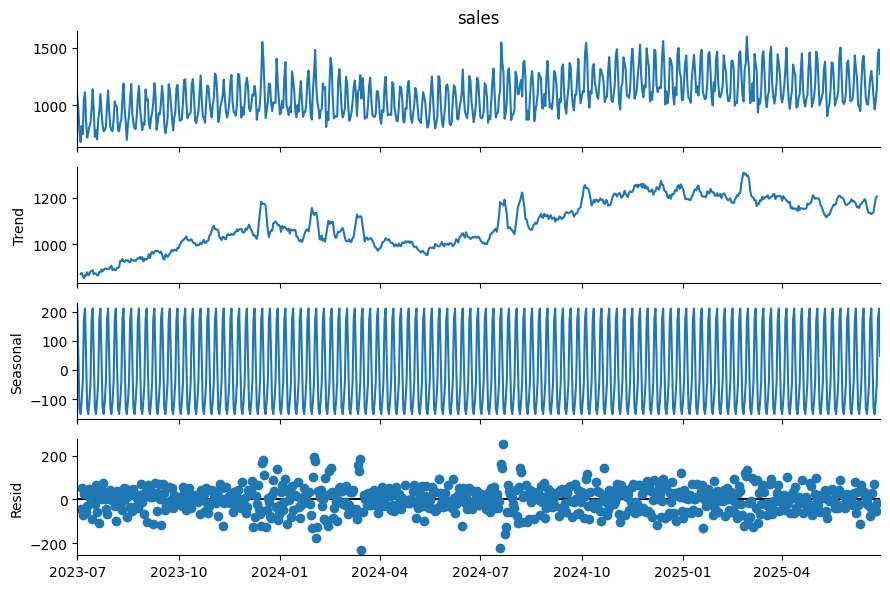

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


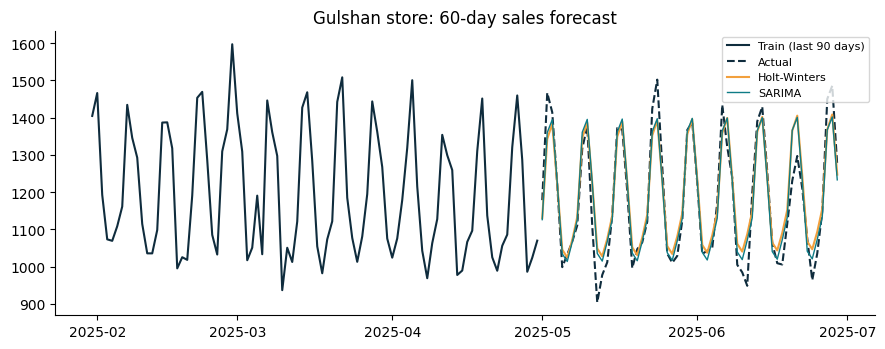

In [9]:
sales = pd.read_excel(DATA, sheet_name="Sales_Data", parse_dates=["date"])
st = sales[sales.store == "Gulshan"].sort_values("date").set_index("date")["sales"]
st.index.freq = "D"
dec = seasonal_decompose(st, model="additive", period=7)
R["sales_decomp"] = dict(
    trend_start=float(dec.trend.dropna().iloc[0]), trend_end=float(dec.trend.dropna().iloc[-1]),
    seasonal_by_dow={d: round(float(v), 1) for d, v in zip(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
        pd.Series(dec.seasonal.values, index=st.index).groupby(st.index.dayofweek).mean().values)},
    resid_sd=float(dec.resid.dropna().std()))
fig = dec.plot(); fig.set_size_inches(9, 6); plt.tight_layout(); plt.show()

H = 60
train, test = st[:-H], st[-H:]
def metr(a, f):
    return dict(RMSE=rmse(a, f), MAE=float(mean_absolute_error(a, f)), MAPE=float(np.mean(np.abs((a - f) / a)) * 100))
fc = {}
fc["Holt-Winters (add trend, add seasonal)"] = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7).fit().forecast(H)
fc["Holt-Winters (damped trend, add seasonal)"] = ExponentialSmoothing(train, trend="add", damped_trend=True, seasonal="add", seasonal_periods=7).fit().forecast(H)
fc["Holt-Winters (add trend, mult seasonal)"] = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=7).fit().forecast(H)
fc["SARIMA(1,1,1)(1,0,1,7)"] = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,1,7)).fit(disp=False).forecast(H)
last_week = train[-7:].values
fc["Seasonal naive (same weekday last week)"] = pd.Series(np.tile(last_week, H // 7 + 1)[:H], index=test.index)
fc["Mean of training data"] = pd.Series(train.mean(), index=test.index)
R["sales_models"] = {k: metr(test.values, v.values) for k, v in fc.items()}
R["sales_test_mean"] = float(test.mean()); R["sales_n"] = [len(train), len(test)]
R["sales_test_range"] = [str(test.index[0].date()), str(test.index[-1].date())]
# annual seasonality check: does a 7-day model leave an annual pattern in the residuals?
hw = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7).fit()
R["sales_resid_corr_lag7"] = float(pd.Series(hw.resid).autocorr(7))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(train[-90:], color=C["navy"], label="Train (last 90 days)")
ax.plot(test, color=C["navy"], ls="--", label="Actual")
ax.plot(fc["Holt-Winters (add trend, add seasonal)"], color=C["amber"], label="Holt-Winters")
ax.plot(fc["SARIMA(1,1,1)(1,0,1,7)"], color=C["teal"], lw=1, label="SARIMA")
ax.set_title("Gulshan store: 60-day sales forecast"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
pd.DataFrame(R['sales_models']).T.round(2).sort_values('RMSE')

,RMSE,MAE,MAPE
"SARIMA(1,1,1)(1,0,1,7)",53.41,40.14,3.44
"Holt-Winters (add trend, mult seasonal)",54.66,40.56,3.51
"Holt-Winters (damped trend, add seasonal)",55.98,42.40,3.58
"Holt-Winters (add trend, add seasonal)",57.73,43.76,3.80
Seasonal naive (same weekday last week),71.44,58.45,4.91
Mean of training data,189.95,149.17,11.77


## Part 3: Waiter tips regression
Baseline (bill only) then refinements: all features, Ridge (alpha by CV), Random Forest (default and regularized). Reported on an 80/20 hold-out **and** on 5x repeated 5-fold CV, because 60 test rows is noisy.

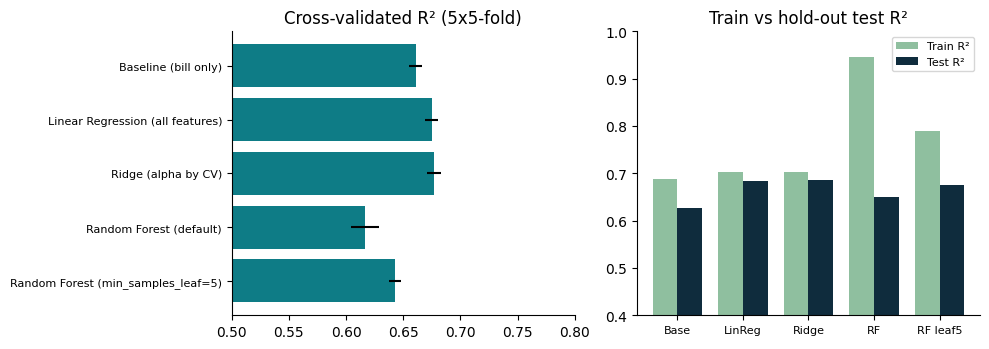

In [11]:
tips = pd.read_excel(DATA, sheet_name="Waiter_Tips")
R["tips_corr"] = float(tips.total_bill.corr(tips["tip"]))
R["tips_n"] = len(tips); R["tips_mean_pct"] = float((tips["tip"] / tips.total_bill).mean() * 100)
R["tips_pct_by"] = {c: (tips.assign(p=tips["tip"] / tips.total_bill * 100).groupby(c).p.mean().round(2).to_dict())
                    for c in ["time", "day", "sex", "smoker"]}
R["tips_pct_by"]["size"] = tips.assign(p=tips["tip"] / tips.total_bill * 100).groupby("size").p.mean().round(2).to_dict()
X, y = tips.drop(columns="tip"), tips["tip"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
cat, num = ["sex", "smoker", "day", "time"], ["total_bill", "size"]
prep = lambda: ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat), ("num", StandardScaler(), num)])
bill_only = ColumnTransformer([("num", StandardScaler(), ["total_bill"])])
models = {
    "Baseline (bill only)": Pipeline([("prep", bill_only), ("model", LinearRegression())]),
    "Linear Regression (all features)": Pipeline([("prep", prep()), ("model", LinearRegression())]),
    "Ridge (alpha by CV)": Pipeline([("prep", prep()), ("model", RidgeCV(alphas=np.logspace(-2, 3, 30)))]),
    "Random Forest (default)": Pipeline([("prep", prep()), ("model", RandomForestRegressor(n_estimators=300, random_state=42))]),
    "Random Forest (min_samples_leaf=5)": Pipeline([("prep", prep()), ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42))]),
}
kf = KFold(5, shuffle=True, random_state=0)
tip_rows = []
for n, m in models.items():
    m.fit(Xtr, ytr); p = m.predict(Xte); ptr = m.predict(Xtr)
    cv_r2, cv_rmse = [], []
    for rep in range(5):                           # 5x repeated 5-fold CV on all 300 rows
        k = KFold(5, shuffle=True, random_state=rep)
        cv_r2.append(cross_val_score(m, X, y, cv=k, scoring="r2").mean())
        cv_rmse.append(-cross_val_score(m, X, y, cv=k, scoring="neg_root_mean_squared_error").mean())
    tip_rows.append(dict(Model=n, Test_R2=r2_score(yte, p), Test_RMSE=rmse(yte, p), Train_R2=r2_score(ytr, ptr),
                         CV_R2=float(np.mean(cv_r2)), CV_R2_sd=float(np.std(cv_r2)), CV_RMSE=float(np.mean(cv_rmse))))
tip_df = pd.DataFrame(tip_rows); R["tips_models"] = tip_df.to_dict("records")
ridge_alpha = float(models["Ridge (alpha by CV)"].named_steps["model"].alpha_); R["ridge_alpha"] = ridge_alpha
lin = models["Linear Regression (all features)"]
names = lin.named_steps["prep"].get_feature_names_out()
R["lin_coefs"] = {str(n): float(c) for n, c in zip(names, lin.named_steps["model"].coef_)}
rf = models["Random Forest (default)"]
R["rf_importance"] = {str(n): float(c) for n, c in zip(rf.named_steps["prep"].get_feature_names_out(), rf.named_steps["model"].feature_importances_)}
# residual noise floor: sd of residuals from the linear model on all data
R["tips_resid_sd"] = float(np.std(ytr - lin.predict(Xtr)))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
o = tip_df.set_index("Model")
ax[0].barh(o.index[::-1], o.CV_R2[::-1], xerr=o.CV_R2_sd[::-1], color=C["teal"]); ax[0].set_xlim(0.5, 0.8)
ax[0].set_title("Cross-validated R² (5x5-fold)"); ax[0].tick_params(axis="y", labelsize=8)
w = 0.38; xs = np.arange(len(o))
ax[1].bar(xs - w/2, o.Train_R2, w, color=C["sage"], label="Train R²"); ax[1].bar(xs + w/2, o.Test_R2, w, color=C["navy"], label="Test R²")
ax[1].set_xticks(xs); ax[1].set_xticklabels(["Base", "LinReg", "Ridge", "RF", "RF leaf5"], fontsize=8)
ax[1].set_ylim(0.4, 1.0); ax[1].legend(fontsize=8); ax[1].set_title("Train vs hold-out test R²")
plt.tight_layout(); plt.show()

In [12]:
tip_df.round(3)

,Model,Test_R2,Test_RMSE,Train_R2,CV_R2,CV_R2_sd,CV_RMSE
0,Baseline (bill only),0.626,0.894,0.688,0.661,0.005,0.833
1,Linear Regression (all features),0.684,0.822,0.703,0.675,0.006,0.815
2,Ridge (alpha by CV),0.685,0.820,0.702,0.677,0.006,0.813
3,Random Forest (default),0.651,0.864,0.945,0.617,0.012,0.884
4,Random Forest (min_samples_leaf=5),0.674,0.834,0.790,0.643,0.005,0.855


## Part 4: Deploy: save and reload the best tips pipeline

In [13]:
# choice made on cross-validated RMSE, with a preference for the simpler model when within noise
best_cv = tip_df.loc[tip_df.CV_RMSE.idxmin()]
R["tips_best_cv"] = best_cv["Model"]
deploy_name = best_cv["Model"]                      # lowest cross-validated RMSE (Ridge also the simplest competitive model)
deploy = models[deploy_name]
deploy.fit(X, y)                                      # final model: refit on ALL rows
joblib.dump(deploy, "tips_pipeline.joblib")
loaded = joblib.load("tips_pipeline.joblib")
new = pd.DataFrame([
    {"total_bill": 45.00, "sex": "Male", "smoker": "No", "day": "Sat", "time": "Dinner", "size": 4},
    {"total_bill": 18.50, "sex": "Female", "smoker": "Yes", "day": "Thur", "time": "Lunch", "size": 2},
    {"total_bill": 72.00, "sex": "Female", "smoker": "No", "day": "Sun", "time": "Dinner", "size": 6},
])
new["predicted_tip"] = loaded.predict(new).round(2)
new["tip_pct"] = (new.predicted_tip / new.total_bill * 100).round(1)
R["deploy"] = dict(model=deploy_name, reload_matches=bool(np.allclose(loaded.predict(new.drop(columns=["predicted_tip", "tip_pct"])), deploy.predict(new.drop(columns=["predicted_tip", "tip_pct"])))),
                   file_kb=round(os.path.getsize("tips_pipeline.joblib") / 1024, 1), predictions=new.to_dict("records"),
                   max_bill_in_training=float(tips.total_bill.max()))

In [14]:
print('Deployed model:', R['deploy']['model'], '| reload matches in-memory model:', R['deploy']['reload_matches'])
new

Deployed model: Ridge (alpha by CV) | reload matches in-memory model: True


,total_bill,sex,smoker,day,time,size,predicted_tip,tip_pct
0,45.0,Male,No,Sat,Dinner,4,6.20,13.8
1,18.5,Female,Yes,Thur,Lunch,2,2.37,12.8
2,72.0,Female,No,Sun,Dinner,6,9.10,12.6


## Discussion notes
- LSTM vs naive baseline, and why a price-level model struggles on a trending series.
- Sales: structured models vs seasonal-naive; differences among the top models are within noise on 60 test days.
- Tips: refinement gain is small because the bill dominates; Random Forest overfits (train R² far above CV R²).
- Deployment: tips as an on-demand service; stock/sales as a scheduled batch job with monitoring against the naive baseline.